In [8]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


In [13]:


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [30]:
 #Load dataset with proper header (skip metadata row)
df = pd.read_csv("UCI_Credit_Card.csv", header=0)

In [31]:
# Drop ID column if it exists
if 'ID' in df.columns:
    df.drop('ID', axis=1, inplace=True)

In [32]:
# Rename target column
df.rename(columns={'default payment next month': 'default'}, inplace=True)


In [33]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())


Missing values:
 LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64


In [48]:
# Scale features
scaler = StandardScaler()
features = df.drop('default', axis=1)
X_scaled = scaler.fit_transform(features)


In [49]:
# Final datasets
X = pd.DataFrame(X_scaled, columns=features.columns)
y = df['default']

In [34]:
print(df.columns.tolist())


['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month']


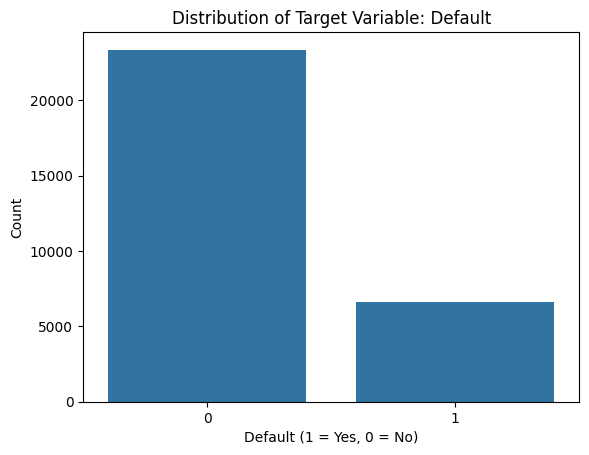

In [50]:
df.rename(columns={'default.payment.next.month': 'default'}, inplace=True)
sns.countplot(x='default', data=df)
plt.title('Distribution of Target Variable: Default')
plt.xlabel('Default (1 = Yes, 0 = No)')
plt.ylabel('Count')
plt.show()


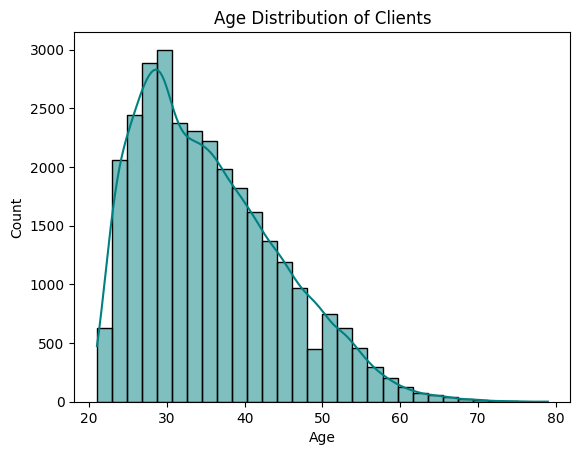

In [51]:

sns.histplot(df['AGE'], bins=30, kde=True, color='teal')
plt.title('Age Distribution of Clients')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


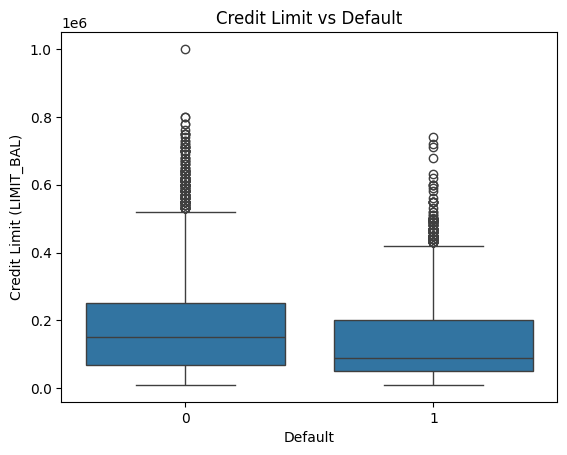

In [52]:
sns.boxplot(x='default', y='LIMIT_BAL', data=df)
plt.title('Credit Limit vs Default')
plt.xlabel('Default')
plt.ylabel('Credit Limit (LIMIT_BAL)')
plt.show()

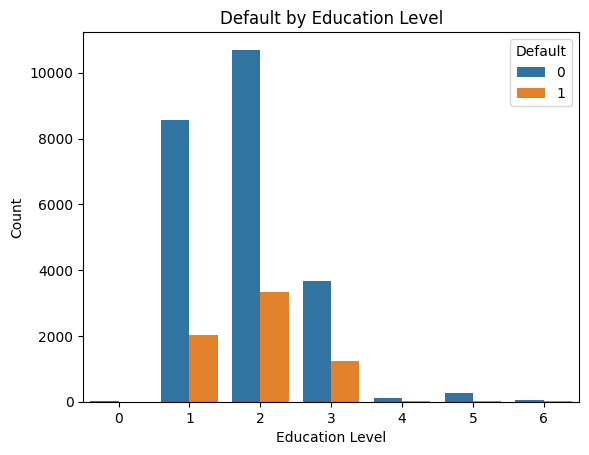

In [53]:
sns.countplot(x='EDUCATION', hue='default', data=df)
plt.title('Default by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.legend(title='Default')
plt.show()


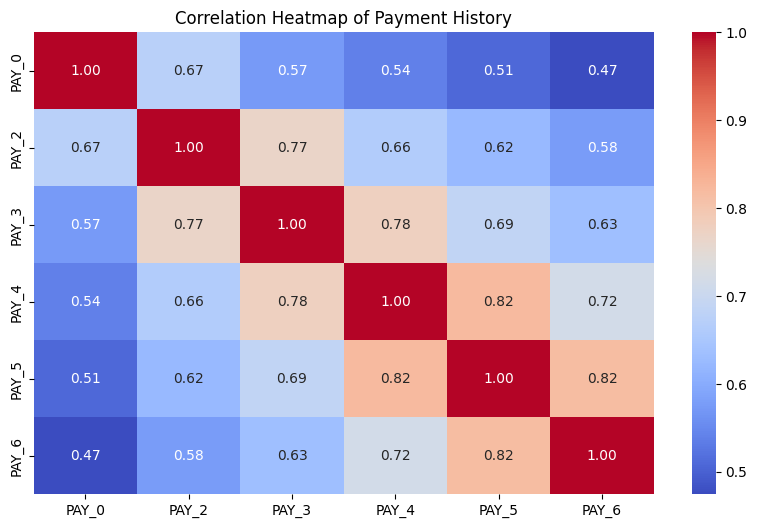

In [54]:
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
plt.figure(figsize=(10, 6))
sns.heatmap(df[pay_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Payment History')
plt.show()


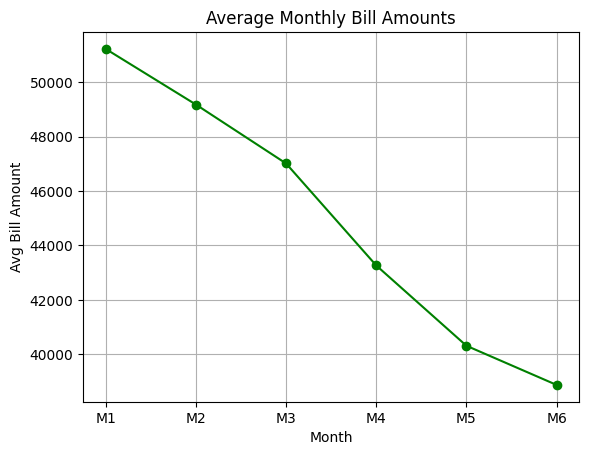

In [55]:
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
avg_bills = df[bill_cols].mean()

plt.plot(range(1, 7), avg_bills, marker='o', color='green')
plt.title('Average Monthly Bill Amounts')
plt.xlabel('Month')
plt.ylabel('Avg Bill Amount')
plt.xticks(range(1, 7), ['M1', 'M2', 'M3', 'M4', 'M5', 'M6'])
plt.grid(True)
plt.show()


In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [57]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'SVM': SVC(probability=True)
}

for name, model in models.items():
    print(f"\n--- {name} ---")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))



--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4687
           1       0.69      0.24      0.35      1313

    accuracy                           0.81      6000
   macro avg       0.76      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000

ROC-AUC: 0.7269748884917869

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4687
           1       0.64      0.36      0.46      1313

    accuracy                           0.82      6000
   macro avg       0.74      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000

ROC-AUC: 0.7600957811229744

--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.83      0.82      0.82      4687
           1       0.38      0.41      0.39      1313

    accuracy                           0.73      60

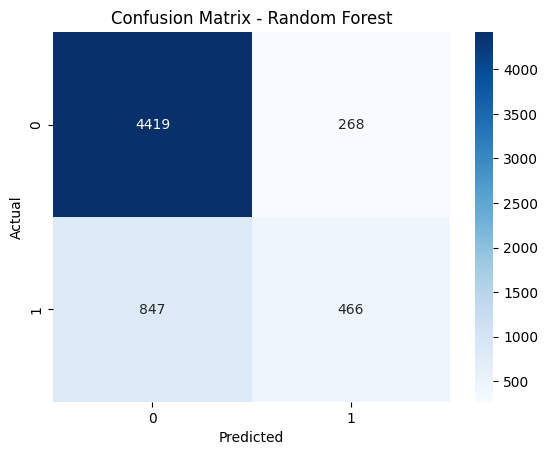

In [58]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


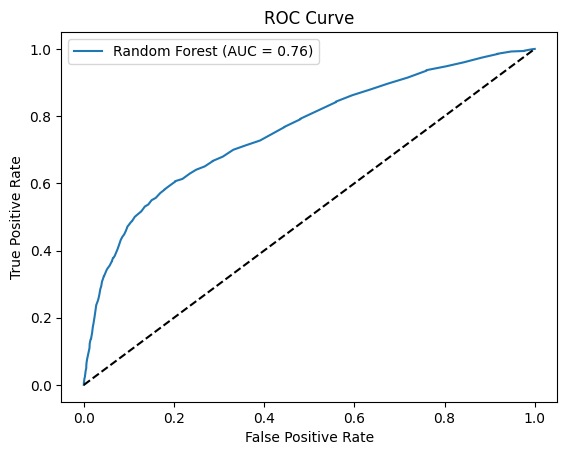

In [59]:
y_proba = rf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr, label="Random Forest (AUC = {:.2f})".format(roc_auc_score(y_test, y_proba)))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


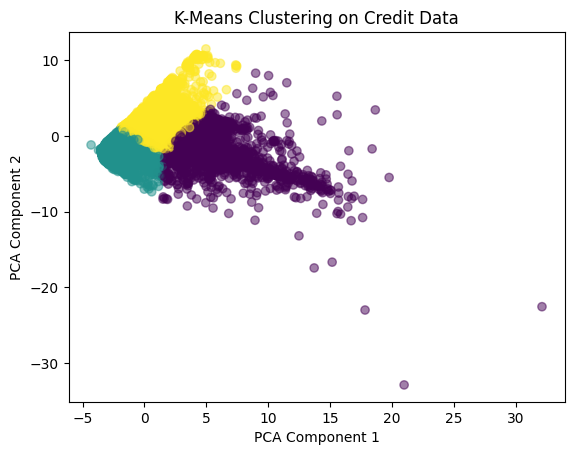

In [60]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.5)
plt.title("K-Means Clustering on Credit Data")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


In [61]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3, scoring='f1', verbose=1)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best F1 Score:", grid.best_score_)


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best F1 Score: 0.47014941250532677
